# Voltametria Cíclica Reversível

As equações governantes são as mesmas da voltametria de varredura linear reversível — segunda lei de Fick adimensionalizada com equilíbrio de Nernst na superfície do eletrodo (eqs. 1.0 a 1.3 do modelo anterior).

A diferença está na forma de aplicação do potencial: após atingir o potencial de inversão $E_f$, a direção da varredura é invertida, permitindo que os processos de redução e oxidação sejam observados em um único experimento. O potencial varia com o tempo segundo:

$$E(\tau) = E_i + v\tau, \quad \text{se} \quad \tau \leq \tau_\lambda \tag{1.4a}$$

$$E(\tau) = E_f - v(\tau - \tau_\lambda), \quad \text{se} \quad \tau_\lambda \leq \tau \leq 2\tau_\lambda \tag{1.4b}$$

onde $v$ é a velocidade de varredura e $\tau_\lambda$ é o tempo de inversão, definido como:

$$\tau_\lambda = \frac{E_f - E_i}{v}$$

O tempo total do experimento é $2\tau_\lambda$, correspondendo à ida e volta da varredura.

## Bibliotecas:

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import Text, Button, HBox, VBox, Output
from IPython.display import display, clear_output

## Definindo o Modelo:

In [2]:
model = pybamm.BaseModel()

concentration_o = pybamm.Variable("Concentração de O", domain="electrolyte")
concentration_r = pybamm.Variable("Concentração de R", domain="electrolyte")

initial_potential  = pybamm.Parameter("Potencial Inicial [V]")
final_potential    = pybamm.Parameter("Potencial Final [V]")
standard_potential = pybamm.Parameter("Potencial Padrão [V]")
scan_rate          = pybamm.Parameter("Velocidade de Varredura [V.s-1]")
faraday            = pybamm.Parameter("Constante de Faraday [C.mol-1]")
gas_constant       = pybamm.Parameter("Constante dos Gases [J.K-1.mol-1]")
temperature        = pybamm.Parameter("Temperatura [K]")
time_scale         = pybamm.Parameter("Escala de tempo [s]")

r_D = pybamm.Parameter("Razão entre os coeficientes de difusão") # DR/DO

flux_o = -pybamm.grad(concentration_o)   # fluxo difusional de O
flux_r = -pybamm.grad(concentration_r)   # fluxo difusional de R

model.rhs = {
    concentration_o: -(1 / time_scale) * pybamm.div(flux_o),
    concentration_r: -(1 / time_scale) * pybamm.div(flux_r),
}

# condições iniciais
theta_i = pybamm.exp(
    faraday * (initial_potential - standard_potential)
    / (gas_constant * temperature)
)

cO_initial = theta_i / (1 + theta_i)
cR_initial = 1 / (1 + theta_i)

model.initial_conditions = {
    concentration_o: cO_initial,  # c_O(x,0) = 1: O uniforme e adimensionalizado
    concentration_r: cR_initial,  # c_R(x,0) = 0: R inicialmente ausente
}

# condições de contorno — Dirichlet
# esquerda (x=0): interface eletrodo/solução — equilíbrio de Nernst, potencial varia ciclicamente
# direita  (x=6): seio da solução            — difusão semi-infinita
nernst_factor     = faraday / (gas_constant * temperature)          # f = F/(RT)
total_time        = 2 * (final_potential - initial_potential) / scan_rate
cosine            = pybamm.cos((np.pi / total_time) * pybamm.t)
sine              = pybamm.sin((np.pi / total_time) * pybamm.t)
applied_potential = initial_potential + (2 * (final_potential - initial_potential) / np.pi) * pybamm.AbsoluteValue(pybamm.arctan(sine / cosine))
overpotential     = applied_potential - standard_potential
theta             = pybamm.exp(nernst_factor * overpotential)

cR_surface = pybamm.boundary_value(concentration_r, "left")
cO_surface = theta * cR_surface # 1.3a
cO_gradient_surface = pybamm.boundary_gradient(concentration_o, "left")
cR_gradient_surface = -(1/r_D) * cO_gradient_surface #1.3b

model.boundary_conditions = {
    concentration_o: {
        "left":  (cO_surface, "Dirichlet"),  # c_O(0,t) = θ/(1+θ) — equilíbrio de Nernst
        "right": (pybamm.Scalar(1),    "Dirichlet"),  # c_O(∞,t) = 1       — difusão semi-infinita
    },
    concentration_r: {
        "left":  (cR_gradient_surface,    "Neumann"),  # c_R(0,t) = 1/(1+θ) — equilíbrio de Nernst
        "right": (pybamm.Scalar(0),    "Dirichlet"),  # c_R(∞,t) = 0       — difusão semi-infinita
    },
}

model.variables = {
    "Concentração de O":  concentration_o,
    "Concentração de R":  concentration_r,
    "Fluxo de O":         flux_o,
    "Fluxo de R":         flux_r,
    "Potencial Aplicado": applied_potential,
}

param = pybamm.ParameterValues(
    {
        "Potencial Inicial [V]":            "[input]",
        "Potencial Final [V]":              "[input]",
        "Potencial Padrão [V]":             "[input]",
        "Velocidade de Varredura [V.s-1]":  "[input]",
        "Constante de Faraday [C.mol-1]":   96485.3,
        "Constante dos Gases [J.K-1.mol-1]": 8.31446,
        "Temperatura [K]":                  298.15,
        "Razão entre os coeficientes de difusão": 1,
        "Escala de tempo [s]": "[input]",
    }
)

## Geometria

In [3]:
# ── Geometria e Malha ─────────────────────────────────────────────────────────

x_variable = pybamm.SpatialVariable(
    "x", domain=["electrolyte"], coord_sys="cartesian"
)

geometry = {
    "electrolyte": {x_variable: {"min": pybamm.Scalar(0), "max": pybamm.Scalar(6)}}
}

## Malha

In [4]:
submesh_types = {
    "electrolyte": pybamm.MeshGenerator(
        pybamm.Exponential1DSubMesh,
        submesh_params={
            "side": "left",
            "stretch": 5,
        },
    )
}
variable_points = {x_variable: 400}
mesh            = pybamm.Mesh(geometry, submesh_types, variable_points)

## Discretização

In [5]:
# ── Discretização ─────────────────────────────────────────────────────────────

spatial_methods = {"electrolyte": pybamm.FiniteVolume()}
discretisation  = pybamm.Discretisation(mesh, spatial_methods)

param.process_model(model)
param.process_geometry(geometry)
discretisation.process_model(model)

## Solver

In [6]:
solver = pybamm.IDAKLUSolver(
    rtol=1e-8,
    atol=1e-10
)

## Gráfico Estático:

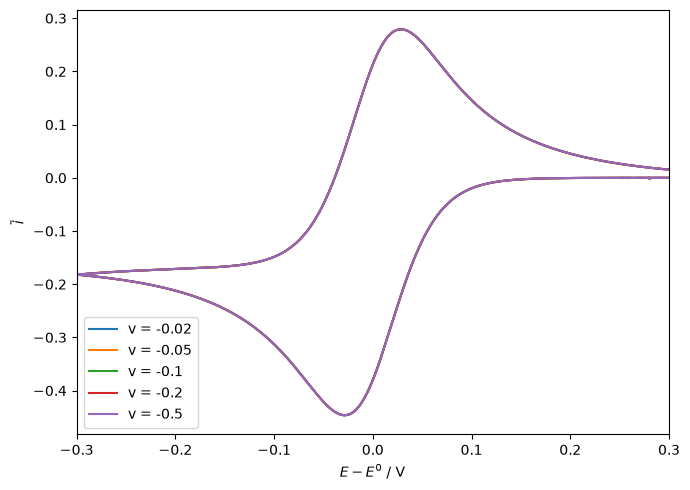

In [7]:
# potenciais fixos para a varredura cíclica
DEFAULT_INITIAL_POTENTIAL  =  0.3   # potencial inicial [V]
DEFAULT_FINAL_POTENTIAL    = -0.3   # potencial final [V]
DEFAULT_STANDARD_POTENTIAL =  0     # potencial padrão [V]

N_ELECTRONS = 1
BULK_CONCENTRATION = 1.0        # mol/m³
DIFFUSION_COEFFICIENT_O = 1e-9  # m²/s

scan_rates    = [-0.02, -0.05, -0.1, -0.2, -0.5]  # velocidades de varredura [V/s]
colors        = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

dimensionless_currents      = []
potentials    = []
dimensionless_peak_currents = []

for scan_rate_i in scan_rates:
        
    final_time = 2 * (DEFAULT_FINAL_POTENTIAL - DEFAULT_INITIAL_POTENTIAL) / scan_rate_i
    tau_s_i = (
    8.31446 * 298.15/ (N_ELECTRONS * 96485.3 * abs(scan_rate_i))
    )
    
    time       = np.linspace(0, final_time, 1000)

    solution = solver.solve(
        model, time,
        inputs={
            "Potencial Inicial [V]":           DEFAULT_INITIAL_POTENTIAL,
            "Potencial Final [V]":             DEFAULT_FINAL_POTENTIAL,
            "Potencial Padrão [V]":            DEFAULT_STANDARD_POTENTIAL,
            "Velocidade de Varredura [V.s-1]": scan_rate_i,
             "Escala de tempo [s]": tau_s_i,
        }
    )

    flux_o_solution            = solution["Fluxo de O"]
    applied_potential_solution = solution["Potencial Aplicado"]

    current   = flux_o_solution(solution.t, x=0)
    potential = applied_potential_solution(solution.t)

    dimensionless_currents.append(current)
    potentials.append(potential)
   # peak_currents.append(np.min(current))  # pico catódico (mínimo, pois a corrente é negativa)

flux_o_solution            = solution["Fluxo de O"]
applied_potential_solution = solution["Potencial Aplicado"]

current   = flux_o_solution(solution.t, x=0)
potential = applied_potential_solution(solution.t)


fig, ax1 = plt.subplots(figsize=(7, 5))

for scan_rate_i, color, dimensionless_current, potential in zip(
    scan_rates,
    colors,
    dimensionless_currents,
    potentials
):
    ax1.plot(
        potential,
        dimensionless_current,
        color=color,
        label=f"v = {scan_rate_i}"
    )
ax1.set_xlabel(r"$E - E^0$ / V")
ax1.set_ylabel(r"$\bar i$")
ax1.set_xlim([DEFAULT_FINAL_POTENTIAL, DEFAULT_INITIAL_POTENTIAL])
ax1.legend(loc="lower left")

plt.tight_layout()
plt.show()

O gráfico da esquerda mostra os voltamogramas cíclicos para cinco velocidades de varredura diferentes. Cada curva apresenta dois picos: um **pico catódico** ($i_{pc}$), associado à redução de $O$ em $R$ na varredura direta, e um **pico anódico** ($i_{pa}$), associado à reoxidação de $R$ em $O$ na varredura inversa.

Para um sistema reversível, os dois picos são simétricos em amplitude e separados por uma diferença de potencial característica. A razão $|i_{pa}/i_{pc}| \approx 1$ e a separação entre os potenciais de pico $\Delta E_p \approx 59/n$ mV (a 25°C) são critérios diagnósticos de reversibilidade eletroquímica.

O gráfico da direita mostra que a corrente de pico cresce linearmente com $\sqrt{v}$, confirmando o controle difusional do processo — comportamento previsto pela equação de Randles-Ševčík:

$$i_p \propto \sqrt{v}$$

## Gráfico Interativo:

In [8]:
# ─────────────────────────────────────────────────────────────────────
# GRÁFICO INTERATIVO
# ─────────────────────────────────────────────────────────────────────
# Parâmetros para recuperação das grandezas dimensionais

FARADAY = 96485.3                  # C mol-1
GAS_CONSTANT = 8.31446             # J K-1 mol-1
TEMPERATURE = 298.15               # K

BULK_CONCENTRATION = 1.0            # mol m-3
DIFFUSION_COEFFICIENT_O = 1e-9      # m2 s-1
N_ELECTRONS = 1

output = Output()


def solve_cyclic_sweep(
    initial_potential,
    final_potential,
    standard_potential,
    scan_rate,
):
    """
    Resolve uma varredura linear de potencial.

    A solução é realizada no modelo adimensional.
    A corrente de saída é posteriormente recuperada
    como densidade de corrente dimensional.
    """

    final_time = 2*(
        final_potential - initial_potential
    ) / scan_rate

    tau_s = (
        GAS_CONSTANT * TEMPERATURE
        / (
            N_ELECTRONS
            * FARADAY
            * abs(scan_rate)
        )
    )

    time = np.linspace(0, final_time, 1000)

    solution = solver.solve(
        model,
        time,
        inputs={
            "Potencial Inicial [V]": initial_potential,
            "Potencial Final [V]": final_potential,
            "Potencial Padrão [V]": standard_potential,
            "Velocidade de Varredura [V.s-1]": scan_rate,
            "Escala de tempo [s]": tau_s,
        }
    )

    dimensionless_current = solution["Fluxo de O"](
        solution.t,
        x=0,
    )

    potential = solution["Potencial Aplicado"](
        solution.t
    )

    current_density = (
        N_ELECTRONS
        * FARADAY
        * BULK_CONCENTRATION
        * np.sqrt(
            DIFFUSION_COEFFICIENT_O / tau_s
        )
        * dimensionless_current
    )

    return {
        "potential": potential,
        "current": current_density,
        "scan_rate": scan_rate,
        "tau_s": tau_s,
    }


# ─────────────────────────────────────────────────────────────────────
# PARÂMETROS EXPERIMENTAIS
# ─────────────────────────────────────────────────────────────────────

initial_potential = 0.3
final_potential = -0.3
standard_potential = 0.0

scan_rates = [
    -0.02,
    -0.05,
    -0.10,
    -0.20,
    -0.50,
]


# ─────────────────────────────────────────────────────────────────────
# SOLUÇÕES
# ─────────────────────────────────────────────────────────────────────

results = []

for scan_rate in scan_rates:

    result = solve_cyclic_sweep(
        initial_potential,
        final_potential,
        standard_potential,
        scan_rate,
    )

    results.append(result)

In [9]:
# ─────────────────────────────────────────────────────────────────────
# VOLTAMOGRAMAS
# ─────────────────────────────────────────────────────────────────────

with output:
    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(8, 5))

    for result in results:
        ax.plot(
            result["potential"],
            result["current"],
            linewidth=2,
            label=f'v = {result["scan_rate"]:.3g} V s$^{{-1}}$'
        )

    ax.set_xlabel(r"$E$ / V")
    ax.set_ylabel(r"$j$ / A m$^{-2}$")
    ax.set_title("Voltamogramas")
    ax.legend()

    plt.show()

display(output)

Output()

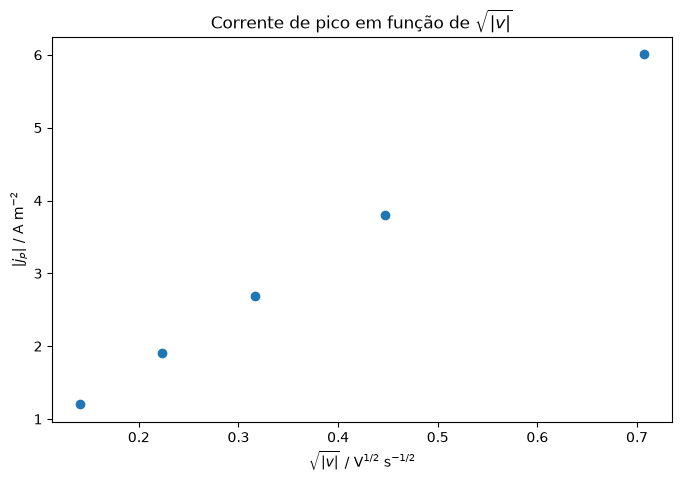

In [10]:
# ─────────────────────────────────────────────────────────────────────
# CORRENTE DE PICO EM FUNÇÃO DA VELOCIDADE DE VARREDURA
# ─────────────────────────────────────────────────────────────────────

peaks = []

for result in results:

    index = np.argmin(result["current"])

    peaks.append({
        "scan_rate": result["scan_rate"],
        "peak_potential": result["potential"][index],
        "peak_current": result["current"][index],
    })


sqrt_scan_rates = np.array([
    np.sqrt(abs(peak["scan_rate"]))
    for peak in peaks
])

peak_currents = np.array([
    abs(peak["peak_current"])
    for peak in peaks
])


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    sqrt_scan_rates,
    peak_currents,
    "o",
    markersize=6,
)

ax.set_xlabel(
    r"$\sqrt{|v|}$ / V$^{1/2}$ s$^{-1/2}$"
)

ax.set_ylabel(
    r"$|j_p|$ / A m$^{-2}$"
)

ax.set_title(
    r"Corrente de pico em função de $\sqrt{|v|}$"
)

plt.show()

In [11]:
# ─────────────────────────────────────────────────────────────────────
# VALIDAÇÃO DE RANDLES–ŠEVČÍK
# ─────────────────────────────────────────────────────────────────────

# Ajuste linear: |jp| = a * sqrt(|v|) + b

coeficients = np.polyfit(
    sqrt_scan_rates,
    peak_currents,
    1,
)

slope = coeficients[0]
intercept = coeficients[1]


# Valores calculados pelo ajuste

fitted_currents = (
    slope * sqrt_scan_rates
    + intercept
)


# Coeficiente de determinação R²

residuals = (
    peak_currents
    - fitted_currents
)

ss_res = np.sum(residuals**2)

ss_tot = np.sum(
    (peak_currents - np.mean(peak_currents))**2
)

r_squared = 1 - ss_res / ss_tot


# Coeficiente teórico de Randles–Ševčík

rs_coefficient = (
    0.4463
    * N_ELECTRONS
    * FARADAY
    * BULK_CONCENTRATION
    * np.sqrt(
        N_ELECTRONS
        * FARADAY
        * DIFFUSION_COEFFICIENT_O
        / (
            GAS_CONSTANT
            * TEMPERATURE
        )
    )
)


print(f"Coeficiente angular numérico = {slope:.6g}")
print(f"Intercepto = {intercept:.6g}")
print(f"R² = {r_squared:.10f}")
print(f"Coeficiente teórico = {rs_coefficient:.6g}")
print(
    f"Erro relativo = "
    f"{100 * abs(slope - rs_coefficient) / rs_coefficient:.6g} %"
)

Coeficiente angular numérico = 8.49591
Intercepto = 4.07811e-09
R² = 1.0000000000
Coeficiente teórico = 8.49541
Erro relativo = 0.0059062 %
